# ADNI Group-Average ENIGMA Cohort Analysis

This notebook summarizes the cohort produced by `scripts/build_cohort.py` for the first group-average ENIGMA FKPP/NDM forecasting experiment.

The goal of this checkpoint is to answer four practical questions before modelling:

1. How many ADNI rows were loaded from each Study File?
2. How many tau PET scans survived quality control?
3. How many longitudinal subject/tracer groups can support forecasting?
4. What does the usable cohort look like by diagnosis, tracer, follow-up time, and tau change?

The notebook reads only generated cohort outputs from `experiments/group_average_enigma/output/`. It does not touch raw ADNI data.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "experiments" / "group_average_enigma" / "output"
print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/nguyenlinhda/Downloads/SPREAD-TOOLBOX
Output directory: /Users/nguyenlinhda/Downloads/SPREAD-TOOLBOX/experiments/group_average_enigma/output


In [2]:
row_counts_path = OUTPUT_DIR / "cohort_row_counts.json"
cohort_path = OUTPUT_DIR / "cohort_longitudinal_tau.csv"
pairs_path = OUTPUT_DIR / "cohort_forecast_pairs.csv"
observations_path = OUTPUT_DIR / "cohort_tau_observations.csv"

with row_counts_path.open() as f:
    row_counts = json.load(f)

cohort = pd.read_csv(cohort_path)
pairs = pd.read_csv(pairs_path)
observations = pd.read_csv(observations_path)

date_cols = ["baseline_tau_date", "next_tau_date", "last_tau_date"]
for col in date_cols:
    if col in cohort:
        cohort[col] = pd.to_datetime(cohort[col], errors="coerce")
for col in ["baseline_tau_date", "target_tau_date"]:
    if col in pairs:
        pairs[col] = pd.to_datetime(pairs[col], errors="coerce")

numeric_cols = [
    "tau_n", "tau_duration_days", "tau_duration_years", "tau_feature_count",
    "baseline_meta_temporal_suvr", "next_meta_temporal_suvr", "last_meta_temporal_suvr",
    "annualized_meta_temporal_suvr_change_baseline_to_last", "education_years",
    "apoe4_dose", "amyloid_scan_count",
]
for col in numeric_cols:
    if col in cohort:
        cohort[col] = pd.to_numeric(cohort[col], errors="coerce")
for col in ["target_time_days", "target_time_years", "baseline_meta_temporal_suvr", "target_meta_temporal_suvr", "annualized_meta_temporal_suvr_change", "amyloid_scan_count"]:
    if col in pairs:
        pairs[col] = pd.to_numeric(pairs[col], errors="coerce")

print(f"Cohort rows: {len(cohort):,}")
print(f"Forecast pairs: {len(pairs):,}")
print(f"Selected tau observations: {len(observations):,}")

Cohort rows: 541
Forecast pairs: 796
Selected tau observations: 1,475


## What The Row Counts Mean

The build script creates a transparent audit trail. These are the most important fields:

- `tau_analysis_rows`: total rows in the Berkeley tau PET regional SUVR table.
- `tau_failed_qc`: tau scans removed because the tau QC flag did not pass.
- `tau_usable_rows`: tau scans retained after scan-date and QC filtering.
- `tau_groups`: subject/tracer groups, because the workflow does not compare SUVR values across tau tracers.
- `tau_groups_skipped_too_short`: groups with fewer than two usable tau scans; these cannot support forecasting.
- `longitudinal_tau_groups`: usable subject/tracer groups with at least two tau scans.
- `forecast_pairs`: baseline-to-target prediction tasks. A subject may contribute baseline-to-next and baseline-to-last targets.
- `selected_tau_observations`: all tau rows used in the final longitudinal cohort.
- `tau_feature_columns`: numeric tau regional/SUVR columns preserved for future region-level modelling.

In [3]:
summary_keys = [
    "tau_analysis_rows", "tau_failed_qc", "tau_usable_rows", "tau_groups",
    "tau_groups_skipped_too_short", "longitudinal_tau_groups", "forecast_pairs",
    "selected_tau_observations", "tau_feature_columns",
]
summary = pd.DataFrame({
    "metric": summary_keys,
    "value": [row_counts[k] for k in summary_keys],
})
display(summary.style.format({"value": "{:,}"}))

,metric,value
0,tau_analysis_rows,"2,489"
1,tau_failed_qc,178
2,tau_usable_rows,"2,311"
3,tau_groups,"1,377"
4,tau_groups_skipped_too_short,836
5,longitudinal_tau_groups,541
6,forecast_pairs,796
7,selected_tau_observations,"1,475"
8,tau_feature_columns,326


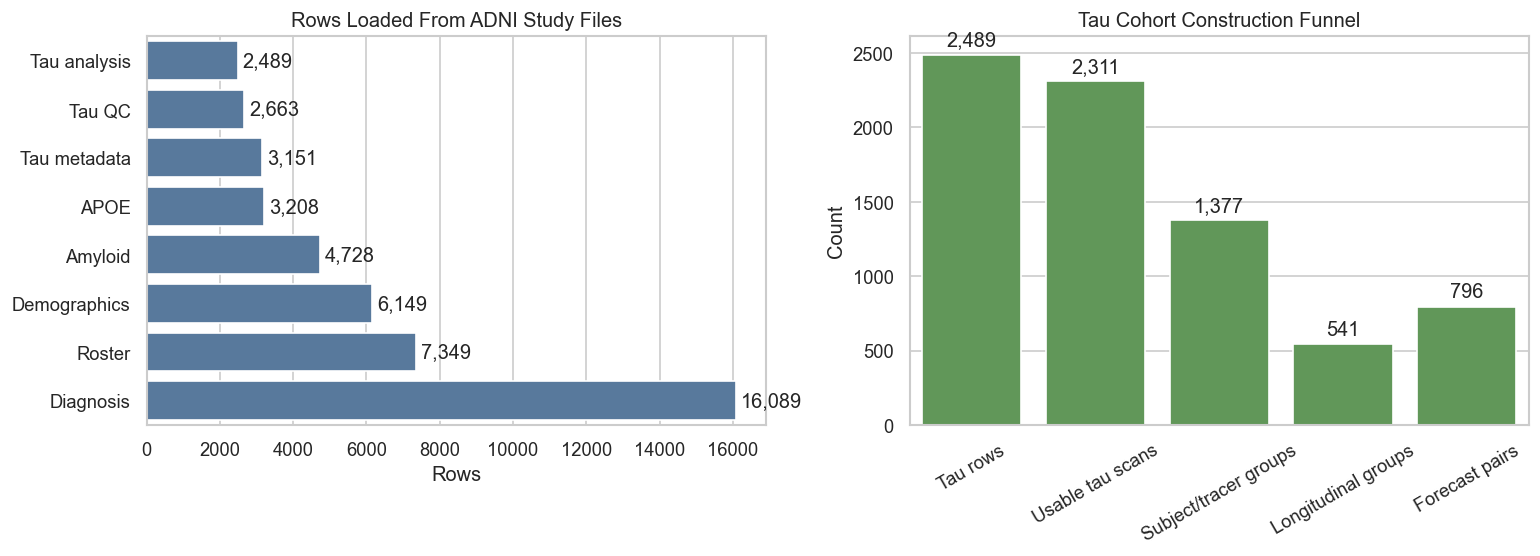

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

source_counts = pd.DataFrame({
    "source": ["Tau analysis", "Tau metadata", "Tau QC", "Amyloid", "Diagnosis", "Demographics", "APOE", "Roster"],
    "rows": [
        row_counts["tau_analysis_rows"], row_counts["tau_metadata_rows"], row_counts["tau_qc_rows"],
        row_counts["amyloid_rows"], row_counts["diagnosis_rows"], row_counts["demographics_rows"],
        row_counts["apoe_rows"], row_counts["roster_rows"],
    ],
}).sort_values("rows")
sns.barplot(data=source_counts, x="rows", y="source", ax=axes[0], color="#4C78A8")
axes[0].set_title("Rows Loaded From ADNI Study Files")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("")

funnel = pd.DataFrame({
    "stage": ["Tau rows", "Usable tau scans", "Subject/tracer groups", "Longitudinal groups", "Forecast pairs"],
    "count": [
        row_counts["tau_analysis_rows"], row_counts["tau_usable_rows"], row_counts["tau_groups"],
        row_counts["longitudinal_tau_groups"], row_counts["forecast_pairs"],
    ],
})
sns.barplot(data=funnel, x="stage", y="count", ax=axes[1], color="#59A14F")
axes[1].set_title("Tau Cohort Construction Funnel")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)

plt.tight_layout()
plt.show()

## Final Cohort Composition

`cohort_longitudinal_tau.csv` has one row per usable subject/tracer group. For this experiment, this table is the main participant-level analysis set.

Important interpretation details:

- A row is not simply a person; it is a `RID + tracer` longitudinal group.
- Same-tracer grouping is deliberate, because the Berkeley table warns not to compare SUVRs across tau tracers.
- Diagnosis is the nearest `DXSUM` diagnosis to baseline tau.
- Baseline is the first usable tau scan after QC; follow-up is the next scan and, where available, the last scan.

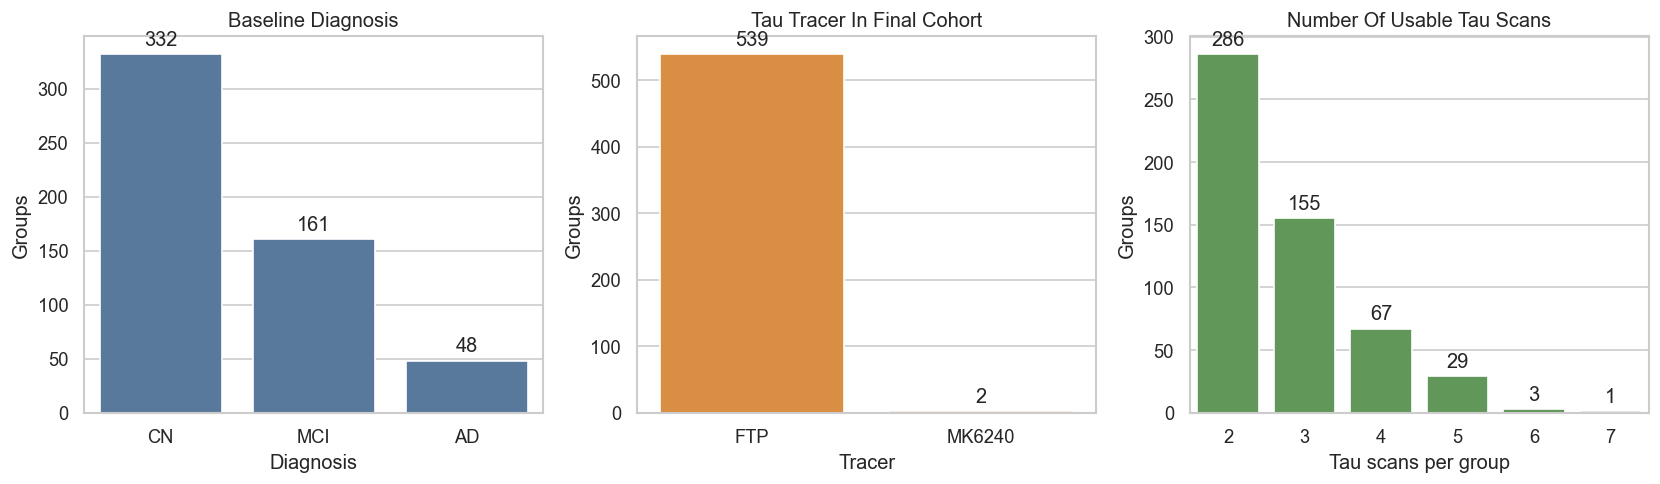

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

dx_order = cohort["dx_nearest_baseline"].fillna("Missing").value_counts().index
sns.countplot(data=cohort, x="dx_nearest_baseline", order=dx_order, ax=axes[0], color="#4C78A8")
axes[0].set_title("Baseline Diagnosis")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Groups")
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}", padding=3)

tracer_order = cohort["TRACER"].value_counts().index
sns.countplot(data=cohort, x="TRACER", order=tracer_order, ax=axes[1], color="#F28E2B")
axes[1].set_title("Tau Tracer In Final Cohort")
axes[1].set_xlabel("Tracer")
axes[1].set_ylabel("Groups")
axes[1].bar_label(axes[1].containers[0], fmt="{:,.0f}", padding=3)

sns.countplot(data=cohort, x="tau_n", ax=axes[2], color="#59A14F")
axes[2].set_title("Number Of Usable Tau Scans")
axes[2].set_xlabel("Tau scans per group")
axes[2].set_ylabel("Groups")
axes[2].bar_label(axes[2].containers[0], fmt="{:,.0f}", padding=3)

plt.tight_layout()
plt.show()

In [6]:
composition = (
    cohort.groupby(["dx_nearest_baseline", "TRACER"], dropna=False)
    .size()
    .rename("groups")
    .reset_index()
    .sort_values(["dx_nearest_baseline", "groups"], ascending=[True, False])
)
display(composition)

,dx_nearest_baseline,TRACER,groups
0,AD,FTP,48
1,CN,FTP,332
2,MCI,FTP,159
3,MCI,MK6240,2


## Follow-Up Time And Forecast Targets

`cohort_forecast_pairs.csv` is the modelling table. Each row says: take this subject/tracer baseline tau pattern and predict this target tau scan.

`target_role` means:

- `next`: the first follow-up tau scan after baseline.
- `last`: the last available follow-up tau scan. This is included only when it differs from the next scan.

This design gives a short-horizon and longer-horizon target where the data allow it.

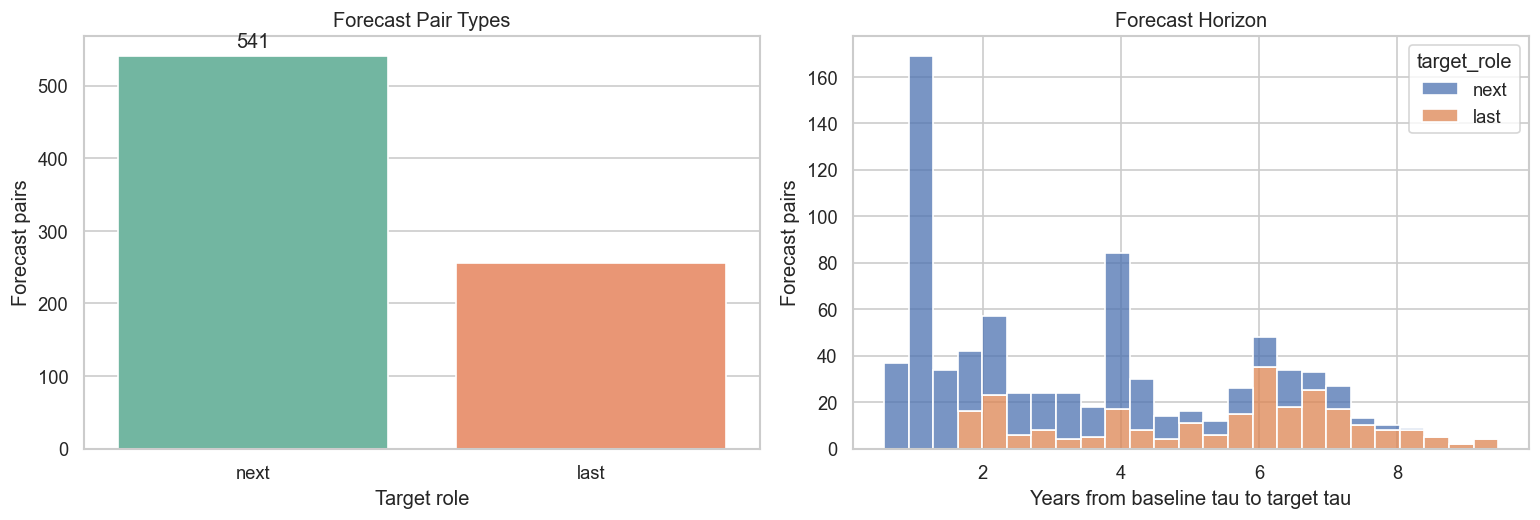

,count,mean,std,min,25%,50%,75%,max
target_role,,,,,,,,
last,255.0,5.35,2.04,1.68,3.90,6.00,6.79,9.46
next,541.0,2.71,1.89,0.57,1.05,2.05,4.01,8.15


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

role_order = pairs["target_role"].value_counts().index
sns.countplot(data=pairs, x="target_role", order=role_order, ax=axes[0], palette="Set2", hue="target_role", legend=False)
axes[0].set_title("Forecast Pair Types")
axes[0].set_xlabel("Target role")
axes[0].set_ylabel("Forecast pairs")
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}", padding=3)

sns.histplot(data=pairs, x="target_time_years", hue="target_role", bins=25, multiple="stack", ax=axes[1])
axes[1].set_title("Forecast Horizon")
axes[1].set_xlabel("Years from baseline tau to target tau")
axes[1].set_ylabel("Forecast pairs")

plt.tight_layout()
plt.show()

display(pairs.groupby("target_role")["target_time_years"].describe().round(2))

## Baseline Tau And Longitudinal Change

These plots use `META_TEMPORAL_SUVR` as a compact scalar summary of tau burden. The actual FKPP/NDM models will use regional tau vectors, but this scalar is useful for sanity checking the cohort.

The annualized change is calculated as:

`(last META_TEMPORAL_SUVR - baseline META_TEMPORAL_SUVR) / years_between_scans`

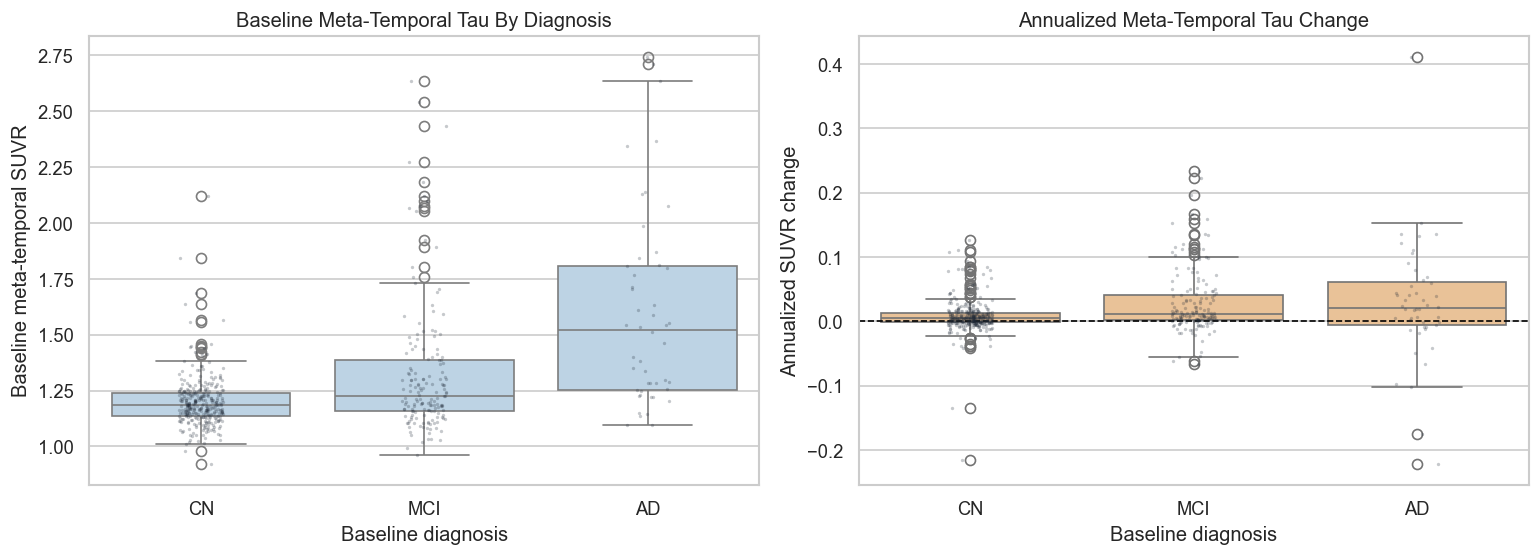

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.boxplot(data=cohort, x="dx_nearest_baseline", y="baseline_meta_temporal_suvr", ax=axes[0], color="#B7D4EA")
sns.stripplot(data=cohort, x="dx_nearest_baseline", y="baseline_meta_temporal_suvr", ax=axes[0], color="#1F2937", alpha=0.25, size=2)
axes[0].set_title("Baseline Meta-Temporal Tau By Diagnosis")
axes[0].set_xlabel("Baseline diagnosis")
axes[0].set_ylabel("Baseline meta-temporal SUVR")

change_col = "annualized_meta_temporal_suvr_change_baseline_to_last"
sns.boxplot(data=cohort, x="dx_nearest_baseline", y=change_col, ax=axes[1], color="#F6C28B")
sns.stripplot(data=cohort, x="dx_nearest_baseline", y=change_col, ax=axes[1], color="#1F2937", alpha=0.25, size=2)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Annualized Meta-Temporal Tau Change")
axes[1].set_xlabel("Baseline diagnosis")
axes[1].set_ylabel("Annualized SUVR change")

plt.tight_layout()
plt.show()

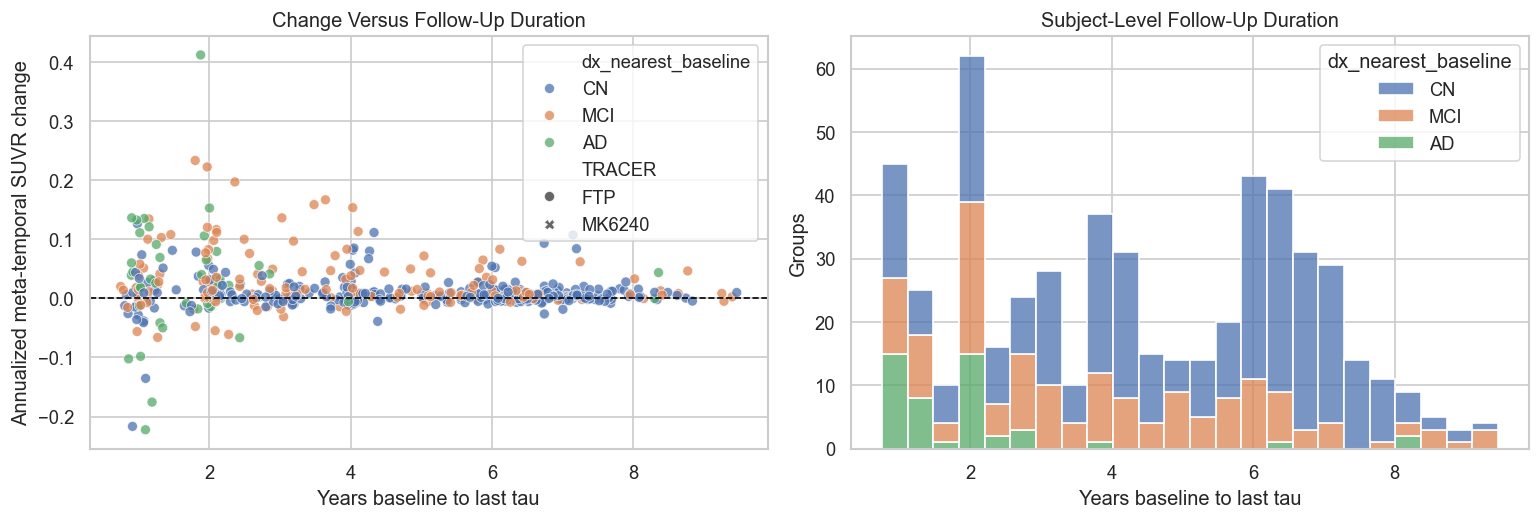

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(
    data=cohort,
    x="tau_duration_years",
    y="annualized_meta_temporal_suvr_change_baseline_to_last",
    hue="dx_nearest_baseline",
    style="TRACER",
    alpha=0.75,
    ax=axes[0],
)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Change Versus Follow-Up Duration")
axes[0].set_xlabel("Years baseline to last tau")
axes[0].set_ylabel("Annualized meta-temporal SUVR change")

sns.histplot(data=cohort, x="tau_duration_years", hue="dx_nearest_baseline", bins=24, multiple="stack", ax=axes[1])
axes[1].set_title("Subject-Level Follow-Up Duration")
axes[1].set_xlabel("Years baseline to last tau")
axes[1].set_ylabel("Groups")

plt.tight_layout()
plt.show()

## Covariate Availability

The cohort builder attaches diagnosis, demographics, APOE, and amyloid scan availability. These fields will be useful for subgroup analysis, epicenter priors, and later ablation experiments.

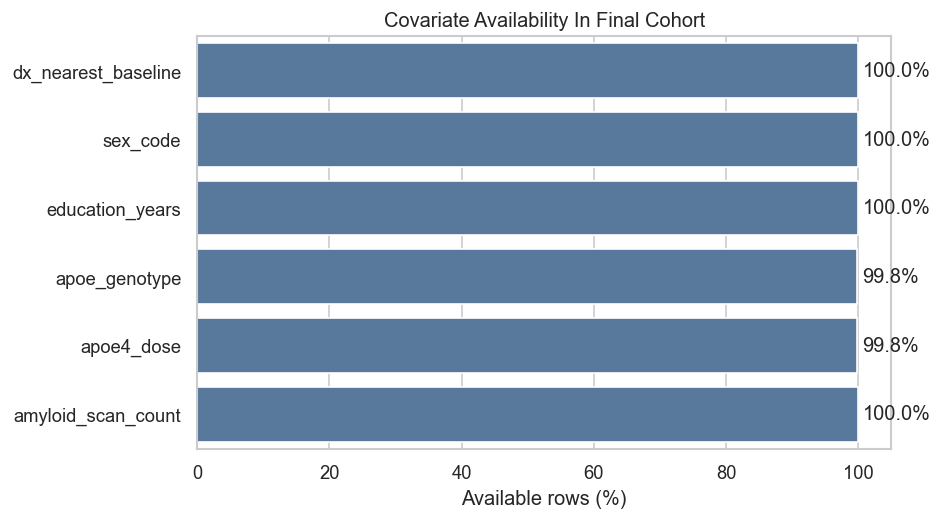

,field,available_rows,missing_rows,available_percent
0,dx_nearest_baseline,541,0,100.0
1,sex_code,541,0,100.0
2,education_years,541,0,100.0
3,apoe_genotype,540,1,99.8
4,apoe4_dose,540,1,99.8
5,amyloid_scan_count,541,0,100.0


In [10]:
covariate_cols = ["dx_nearest_baseline", "sex_code", "education_years", "apoe_genotype", "apoe4_dose", "amyloid_scan_count"]
availability = pd.DataFrame({
    "field": covariate_cols,
    "available_rows": [cohort[col].notna().sum() if col in cohort else 0 for col in covariate_cols],
})
availability["missing_rows"] = len(cohort) - availability["available_rows"]
availability["available_percent"] = 100 * availability["available_rows"] / len(cohort)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=availability, x="available_percent", y="field", color="#4C78A8", ax=ax)
ax.set_title("Covariate Availability In Final Cohort")
ax.set_xlabel("Available rows (%)")
ax.set_ylabel("")
ax.set_xlim(0, 105)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

display(availability.round(1))

## Takeaways For The Next Step

This cohort is suitable for the first group-average connectome forecasting experiment:

- There are hundreds of same-tracer longitudinal tau groups, mostly FTP.
- There are more forecast pairs than subjects because some subjects have both next-scan and last-scan targets.
- The regional tau table preserves hundreds of numeric tau/SUVR columns for atlas mapping.
- The next technical checkpoint is region alignment: ADNI tau regional columns must map cleanly to ENIGMA `aparc` regions 

After region mapping, the workflow can build the ENIGMA group-average Laplacian and start with the NDM sanity-check baseline.

## Pipeline For ENIGMA Or ANY Other Group-Average Connectome 
ADNI longitudinal tau cohort
- choose normative connectome
- map ADNI tau regions to connectome atlas
- build graph Laplacian
- run NDM/FKPP
- evaluate predicted follow-up tau